# Federated Learning Evaluation Visualization Notebook

This notebook visualizes four JSON files:

- `id_eval_results.json` — in-distribution test results
- `ood_eval_results.json` — out-of-distribution test results
- `ood_summary.json` — combined ID vs OOD summary and generalization gap
- `mia_results.json` — membership inference attack results

In [4]:
from pathlib import Path
import json

import pandas as pd
import matplotlib.pyplot as plt

base_dir = Path('/s/chopin/a/grad/C837864364/Projects/Federated-Thoracic-Pathology-Classification/metrics/results')

id_path = base_dir / 'id_eval_results.json'
ood_path = base_dir / 'ood_eval_results.json'
ood_summary_path = base_dir / 'ood_summary.json'
mia_path = base_dir / 'mia_results.json'

with open(id_path, 'r') as f:
    id_results = json.load(f)

with open(ood_path, 'r') as f:
    ood_results = json.load(f)

with open(ood_summary_path, 'r') as f:
    ood_summary = json.load(f)

with open(mia_path, 'r') as f:
    mia_results = json.load(f)

In [5]:
# Overall ID vs OOD metrics
main_metrics = ['auroc_macro', 'f1_macro', 'recall_macro', 'precision_macro', 'loss']

overall_df = pd.DataFrame({
    'metric': main_metrics,
    'ID Test': [id_results[m] for m in main_metrics],
    'OOD Test': [ood_results[m] for m in main_metrics]
})

overall_df['Gap (ID - OOD)'] = overall_df['ID Test'] - overall_df['OOD Test']
overall_df

,metric,ID Test,OOD Test,Gap (ID - OOD)
0,auroc_macro,0.768677,0.761394,0.007283
1,f1_macro,0.271542,0.258579,0.012963
2,recall_macro,0.300777,0.292727,0.008050
3,precision_macro,0.274194,0.256759,0.017435
4,loss,0.412349,0.422804,-0.010455


In [7]:
id_class_auroc = pd.Series(id_results['per_class_auroc'], name='ID AUROC')
ood_class_auroc = pd.Series(ood_results['per_class_auroc'], name='OOD AUROC')

class_df = pd.concat([id_class_auroc, ood_class_auroc], axis=1).reset_index()
class_df = class_df.rename(columns={'index': 'class'})
class_df['AUROC Gap (ID - OOD)'] = class_df['ID AUROC'] - class_df['OOD AUROC']
class_df = class_df.sort_values('ID AUROC', ascending=False)
class_df

,class,ID AUROC,OOD AUROC,AUROC Gap (ID - OOD)
10,Emphysema,0.879616,0.848158,0.031458
7,Pneumothorax,0.846497,0.807671,0.038825
9,Edema,0.840912,0.851972,-0.011060
2,Effusion,0.826738,0.840682,-0.013944
1,Cardiomegaly,0.825362,0.839026,-0.013664
13,Hernia,0.777154,0.911676,-0.134523
8,Consolidation,0.767697,0.684667,0.083030
11,Fibrosis,0.753569,0.799591,-0.046023
4,Mass,0.746227,0.718781,0.027447
0,Atelectasis,0.731460,0.710214,0.021246


In [8]:
# Membership inference attack metrics
mia = mia_results['mia']

mia_df = pd.DataFrame({
    'metric': [
        'mia_vulnerability_balanced_accuracy',
        'attack_auc',
        'member_tpr',
        'non_member_tnr',
        'member_loss_mean',
        'non_member_loss_mean'
    ],
    'value': [
        mia['mia_vulnerability_balanced_accuracy'],
        mia['attack_auc'],
        mia['member_tpr'],
        mia['non_member_tnr'],
        mia['member_loss_mean'],
        mia['non_member_loss_mean']
    ]
})

mia_df

,metric,value
0,mia_vulnerability_balanced_accuracy,0.528320
1,attack_auc,0.504147
2,member_tpr,0.923828
3,non_member_tnr,0.132812
4,member_loss_mean,0.416785
5,non_member_loss_mean,0.416835


## 3. Quick summary numbers


In [13]:
print('ID Test')
print(f"Samples: {id_results['num_samples']}")
print(f"Macro AUROC: {id_results['auroc_macro']:.4f}")
print(f"Macro F1: {id_results['f1_macro']:.4f}")
print(f"Loss: {id_results['loss']:.4f}")

print('\nOOD Test')
print(f"Samples: {ood_results['num_samples']}")
print(f"Macro AUROC: {ood_results['auroc_macro']:.4f}")
print(f"Macro F1: {ood_results['f1_macro']:.4f}")
print(f"Loss: {ood_results['loss']:.4f}")

print('\nOOD Generalization Gap ')
print(f"AUROC Gap (ID - OOD): {ood_summary['ood_generalization_gap']['auroc_gap_id_minus_ood']:.4f}")

print('\n MIA ')
print(f"Attack Balanced Accuracy: {mia['mia_vulnerability_balanced_accuracy']:.4f}")
print(f"Attack AUC: {mia['attack_auc']:.4f}")
# print(mia['interpretation'])

ID Test
Samples: 2413
Macro AUROC: 0.7687
Macro F1: 0.2715
Loss: 0.4123

OOD Test
Samples: 1222
Macro AUROC: 0.7614
Macro F1: 0.2586
Loss: 0.4228

OOD Generalization Gap 
AUROC Gap (ID - OOD): 0.0073

 MIA 
Attack Balanced Accuracy: 0.5283
Attack AUC: 0.5041


## Overall ID vs OOD performance


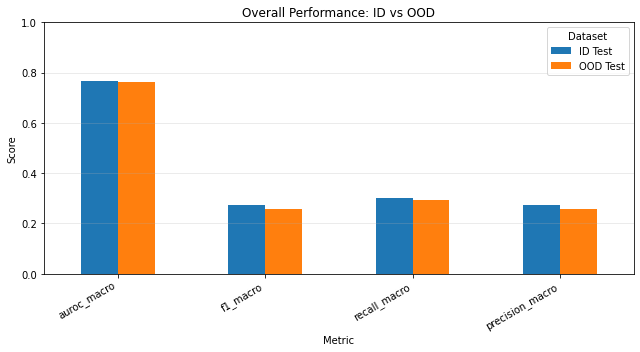

In [14]:
plot_metrics = ['auroc_macro', 'f1_macro', 'recall_macro', 'precision_macro']
plot_df = overall_df[overall_df['metric'].isin(plot_metrics)].set_index('metric')[['ID Test', 'OOD Test']]

ax = plot_df.plot(kind='bar', figsize=(9, 5))
plt.title('Overall Performance: ID vs OOD')
plt.ylabel('Score')
plt.xlabel('Metric')
plt.xticks(rotation=30, ha='right')
plt.ylim(0, 1)
plt.legend(title='Dataset')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

## Loss comparison


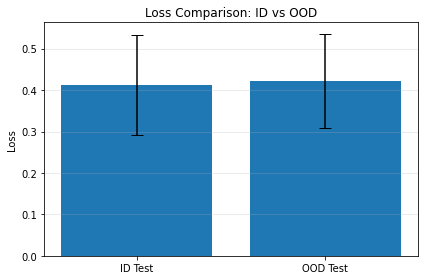

,Dataset,Loss,Loss Std
0,ID Test,0.412349,0.119863
1,OOD Test,0.422804,0.113770


In [15]:
loss_df = pd.DataFrame({
    'Dataset': ['ID Test', 'OOD Test'],
    'Loss': [id_results['loss'], ood_results['loss']],
    'Loss Std': [id_results['loss_std'], ood_results['loss_std']]
})

plt.figure(figsize=(6, 4))
plt.bar(loss_df['Dataset'], loss_df['Loss'], yerr=loss_df['Loss Std'], capsize=6)
plt.title('Loss Comparison: ID vs OOD')
plt.ylabel('Loss')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

loss_df

## Per-class AUROC comparison

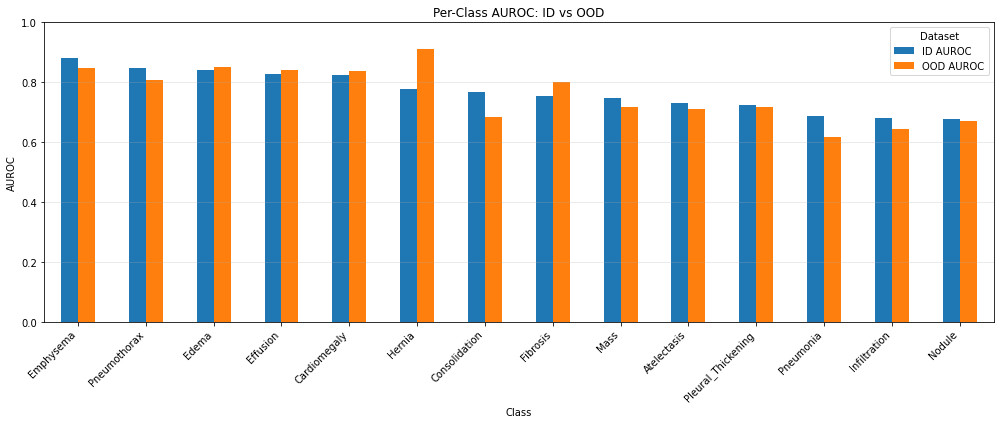

In [16]:
class_plot_df = class_df.set_index('class')[['ID AUROC', 'OOD AUROC']]

ax = class_plot_df.plot(kind='bar', figsize=(14, 6))
plt.title('Per-Class AUROC: ID vs OOD')
plt.ylabel('AUROC')
plt.xlabel('Class')
plt.xticks(rotation=45, ha='right')
plt.ylim(0, 1)
plt.grid(axis='y', alpha=0.3)
plt.legend(title='Dataset')
plt.tight_layout()
plt.show()

## AUROC generalization gap by class

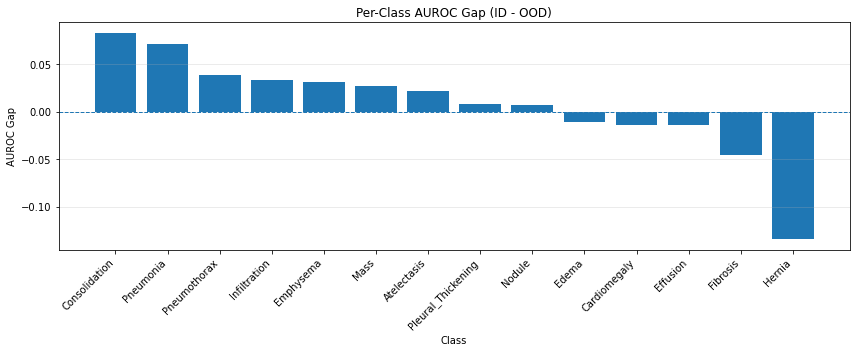

,class,AUROC Gap (ID - OOD)
8,Consolidation,0.083030
6,Pneumonia,0.070839
7,Pneumothorax,0.038825
3,Infiltration,0.033708
10,Emphysema,0.031458
4,Mass,0.027447
0,Atelectasis,0.021246
12,Pleural_Thickening,0.007921
5,Nodule,0.006706
9,Edema,-0.011060


In [17]:
gap_df = class_df.sort_values('AUROC Gap (ID - OOD)', ascending=False)

plt.figure(figsize=(12, 5))
plt.bar(gap_df['class'], gap_df['AUROC Gap (ID - OOD)'])
plt.axhline(0, linestyle='--', linewidth=1)
plt.title('Per-Class AUROC Gap (ID - OOD)')
plt.ylabel('AUROC Gap')
plt.xlabel('Class')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

gap_df[['class', 'AUROC Gap (ID - OOD)']]

## Best and worst classes by OOD AUROC

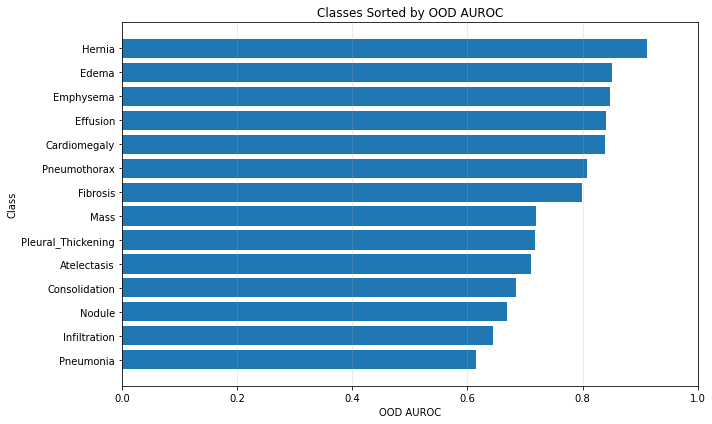

Best OOD class:


,class,ID AUROC,OOD AUROC,AUROC Gap (ID - OOD)
13,Hernia,0.777154,0.911676,-0.134523


Worst OOD class:


,class,ID AUROC,OOD AUROC,AUROC Gap (ID - OOD)
6,Pneumonia,0.686501,0.615662,0.070839


In [18]:
ood_sorted = class_df.sort_values('OOD AUROC', ascending=True)

plt.figure(figsize=(10, 6))
plt.barh(ood_sorted['class'], ood_sorted['OOD AUROC'])
plt.title('Classes Sorted by OOD AUROC')
plt.xlabel('OOD AUROC')
plt.ylabel('Class')
plt.xlim(0, 1)
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

print('Best OOD class:')
display(ood_sorted.tail(1))

print('Worst OOD class:')
display(ood_sorted.head(1))

## Membership inference attack metrics



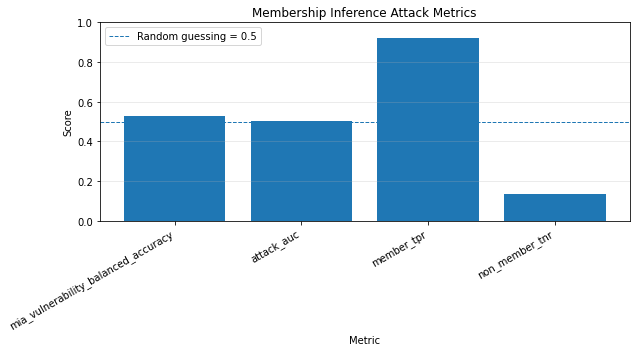

,metric,value
0,mia_vulnerability_balanced_accuracy,0.528320
1,attack_auc,0.504147
2,member_tpr,0.923828
3,non_member_tnr,0.132812


In [19]:
privacy_plot_df = mia_df[mia_df['metric'].isin([
    'mia_vulnerability_balanced_accuracy',
    'attack_auc',
    'member_tpr',
    'non_member_tnr'
])]

plt.figure(figsize=(9, 5))
plt.bar(privacy_plot_df['metric'], privacy_plot_df['value'])
plt.axhline(0.5, linestyle='--', linewidth=1, label='Random guessing = 0.5')
plt.title('Membership Inference Attack Metrics')
plt.ylabel('Score')
plt.xlabel('Metric')
plt.xticks(rotation=30, ha='right')
plt.ylim(0, 1)
plt.legend()
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

privacy_plot_df

## Member vs non-member loss



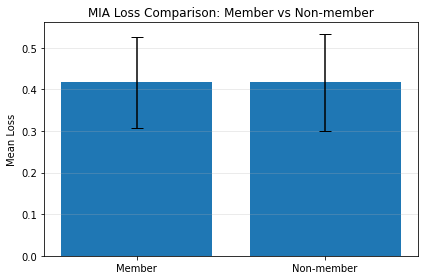

,Group,Mean Loss,Loss Std
0,Member,0.416785,0.108863
1,Non-member,0.416835,0.117362


In [20]:
loss_mia_df = pd.DataFrame({
    'Group': ['Member', 'Non-member'],
    'Mean Loss': [mia['member_loss_mean'], mia['non_member_loss_mean']],
    'Loss Std': [mia['member_loss_std'], mia['non_member_loss_std']]
})

plt.figure(figsize=(6, 4))
plt.bar(loss_mia_df['Group'], loss_mia_df['Mean Loss'], yerr=loss_mia_df['Loss Std'], capsize=6)
plt.title('MIA Loss Comparison: Member vs Non-member')
plt.ylabel('Mean Loss')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

loss_mia_df

##  Final interpretation 

In [ ]:
print("The global model achieved a macro AUROC of 0.7687 on the in-distribution test set and 0.7614 on the out-of-distribution test set.\
The AUROC generalization gap was 0.0073, where a positive value means the model performed better on ID data than OOD data.\
For privacy evaluation, the membership inference attack achieved a balanced accuracy of 0.5283 and an attack AUC of 0.5041.\
Since an attack AUC close to 0.5 indicates near-random guessing, these results suggest limited membership leakage under this loss-threshold attack.")


The global model achieved a macro AUROC of 0.7687 on the in-distribution test set and 0.7614 on the out-of-distribution test set.
The AUROC generalization gap was 0.0073, where a positive value means the model performed better on ID data than OOD data.

For privacy evaluation, the membership inference attack achieved a balanced accuracy of 0.5283 and an attack AUC of 0.5041.
Since an attack AUC close to 0.5 indicates near-random guessing, these results suggest limited membership leakage under this loss-threshold attack.

